Loaded 165 final-metric rows from results/histories
Stages: ['finetune', 'pretrain', 'reverse']
- finetune: 75 rows | corr=[0.0, 0.25, 0.5, 0.75, 1.0]
  concentrations=[0.1, 0.3, 0.5, 0.7, 0.9]
- pretrain: 15 rows | corr=[0.0, 0.25, 0.5, 0.75, 1.0]
- reverse: 75 rows | corr=[0.0, 0.25, 0.5, 0.75, 1.0]
  concentrations=[0.1, 0.3, 0.5, 0.7, 0.9]


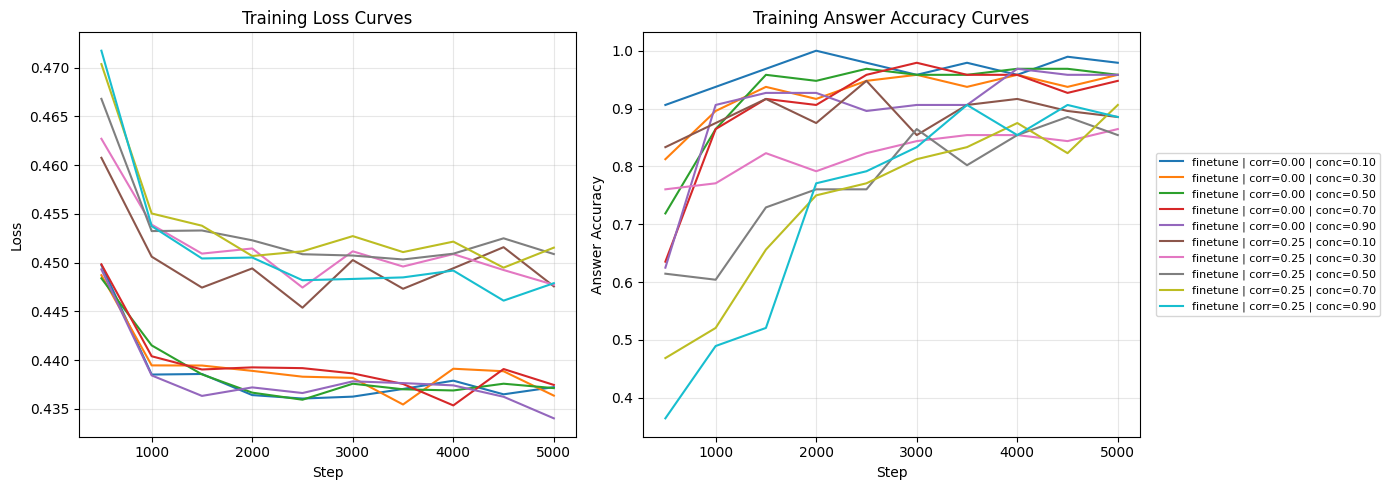

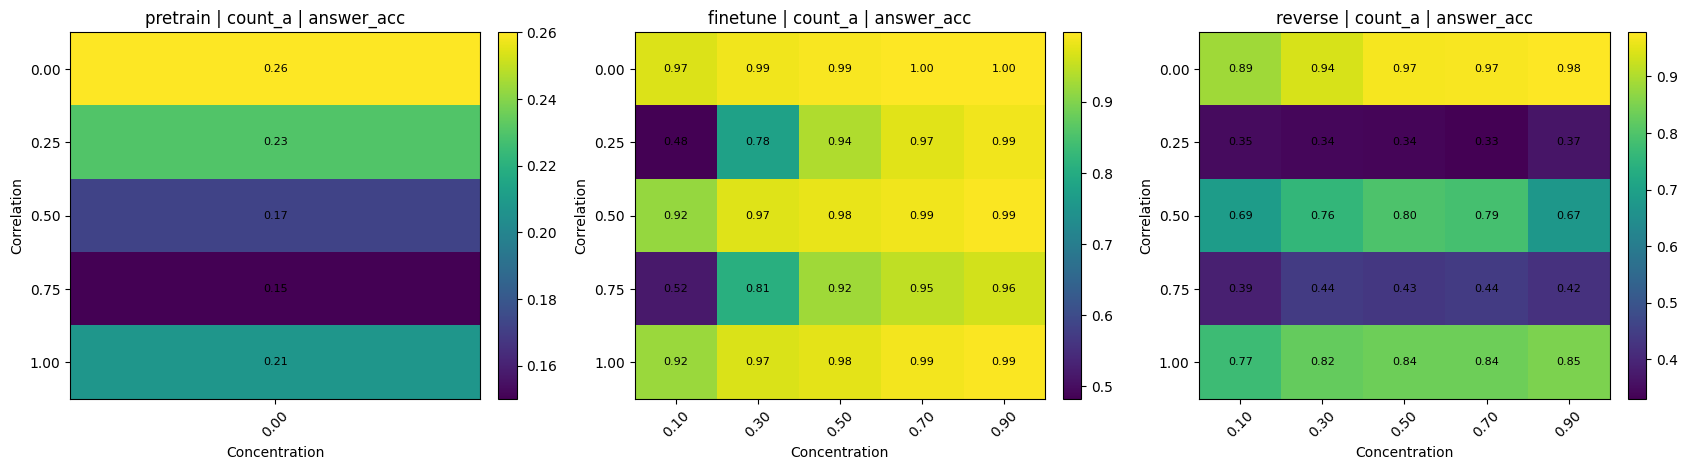

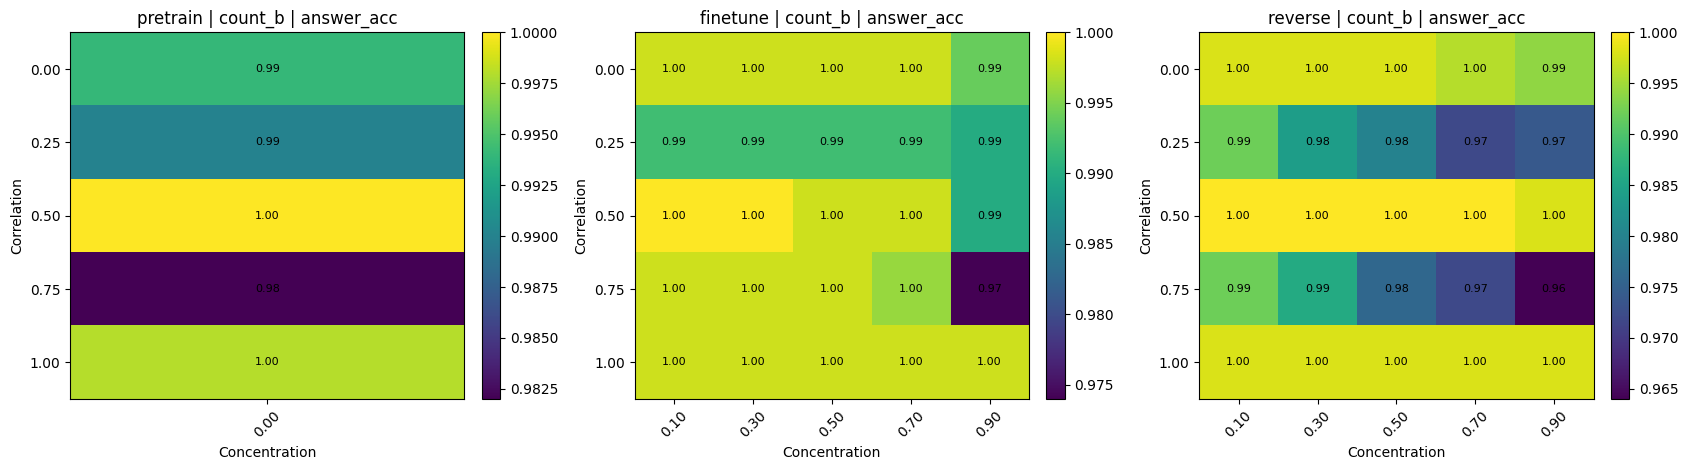

In [1]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

# -----------------------------
# Config
# -----------------------------
RESULTS_DIR = Path("results")
HIST_DIR = RESULTS_DIR / "histories"

# Which splits/metrics to visualize from each history dict
SPLITS = ["count_a", "count_b", "all_other_avg"]
METRICS = ["loss", "answer_acc"]


def parse_run_metadata(file_name: str):
    """Extract stage/correlation/concentration from history file name."""
    patterns = [
        (r"^pretrain_corr_([0-9]+\.[0-9]+)_history\.pth$", "pretrain"),
        (r"^finetune_corr_([0-9]+\.[0-9]+)_conc_([0-9]+\.[0-9]+)_history\.pth$", "finetune"),
        (r"^reverse_corr_([0-9]+\.[0-9]+)_conc_([0-9]+\.[0-9]+)_history\.pth$", "reverse"),
    ]

    for pattern, stage in patterns:
        m = re.match(pattern, file_name)
        
        if not m:
            continue
        if stage == "pretrain":
            corr = float(m.group(1))
            return {"stage": stage, "corr": corr, "conc": None}
        corr = float(m.group(1))
        conc = float(m.group(2))
        return {"stage": stage, "corr": corr, "conc": conc}

    return None


def load_history(path: Path):
    # Stored with torch.save(history, path)
    return torch.load(path, map_location="cpu")


def get_final(history: dict, split: str, metric: str):
    vals = history.get("val", {}).get(split, {}).get(metric, [])
    if not vals:
        return np.nan
    return vals[-1]


def collect_runs(hist_dir: Path):
    records = []
    curve_store = []

    for path in sorted(hist_dir.glob("*_history.pth")):
        meta = parse_run_metadata(path.name)
        if meta is None:
            continue

        hist = load_history(path)

        # Store curves if present
        steps = hist.get("steps", [])
        train_loss = hist.get("train_loss", [])
        train_acc = hist.get("train_answer_acc", [])

        if steps and train_loss:
            curve_store.append(
                {
                    "name": path.name,
                    "stage": meta["stage"],
                    "corr": meta["corr"],
                    "conc": meta["conc"],
                    "steps": np.array(steps),
                    "train_loss": np.array(train_loss),
                    "train_acc": np.array(train_acc) if train_acc else None,
                }
            )

        # Final validation metrics
        for split in SPLITS:
            rec = {
                "file": path.name,
                "stage": meta["stage"],
                "corr": meta["corr"],
                "conc": meta["conc"],
                "split": split,
            }
            for metric in METRICS:
                rec[metric] = get_final(hist, split, metric)
            records.append(rec)

    return records, curve_store


def print_summary(records):
    if not records:
        print("No history files found in", HIST_DIR)
        return

    stages = sorted({r["stage"] for r in records})
    print(f"Loaded {len(records)} final-metric rows from {HIST_DIR}")
    print("Stages:", stages)

    for stage in stages:
        stage_rows = [r for r in records if r["stage"] == stage]
        corrs = sorted({r["corr"] for r in stage_rows})
        concs = sorted({r["conc"] for r in stage_rows if r["conc"] is not None})
        print(f"- {stage}: {len(stage_rows)} rows | corr={corrs}")
        if concs:
            print(f"  concentrations={concs}")


def plot_training_curves(curves, max_runs=8):
    if not curves:
        print("No training curves to plot.")
        return

    # Plot a subset for readability
    chosen = curves[:max_runs]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for c in chosen:
        label = f"{c['stage']} | corr={c['corr']:.2f}"
        if c["conc"] is not None:
            label += f" | conc={c['conc']:.2f}"
        axes[0].plot(c["steps"], c["train_loss"], label=label)

    axes[0].set_title("Training Loss Curves")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)

    for c in chosen:
        if c["train_acc"] is None or len(c["train_acc"]) == 0:
            continue
        label = f"{c['stage']} | corr={c['corr']:.2f}"
        if c["conc"] is not None:
            label += f" | conc={c['conc']:.2f}"
        axes[1].plot(c["steps"], c["train_acc"], label=label)

    axes[1].set_title("Training Answer Accuracy Curves")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Answer Accuracy")
    axes[1].grid(alpha=0.3)

    # Keep legend outside to reduce overlap
    axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    plt.tight_layout()
    plt.show()


def _make_matrix(records, stage, split, metric):
    rows = [r for r in records if r["stage"] == stage and r["split"] == split]
    if not rows:
        return None, None, None

    corrs = sorted({r["corr"] for r in rows})
    concs = sorted({r["conc"] for r in rows if r["conc"] is not None})

    # Pretrain has no concentration; return a vector-like matrix
    if not concs:
        mat = np.full((len(corrs), 1), np.nan)
        for i, corr in enumerate(corrs):
            vals = [r[metric] for r in rows if r["corr"] == corr]
            if vals:
                mat[i, 0] = np.nanmean(vals)
        return mat, corrs, [0.0]

    mat = np.full((len(corrs), len(concs)), np.nan)
    for i, corr in enumerate(corrs):
        for j, conc in enumerate(concs):
            vals = [
                r[metric]
                for r in rows
                if r["corr"] == corr and r["conc"] == conc
            ]
            if vals:
                mat[i, j] = np.nanmean(vals)

    return mat, corrs, concs


def plot_heatmaps(records, split="count_a", metric="answer_acc"):
    stages = ["pretrain", "finetune", "reverse"]
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    for ax, stage in zip(axes, stages):
        mat, corrs, concs = _make_matrix(records, stage, split, metric)
        if mat is None:
            ax.set_title(f"{stage}: no data")
            ax.axis("off")
            continue

        im = ax.imshow(mat, aspect="auto", interpolation="nearest")
        ax.set_title(f"{stage} | {split} | {metric}")
        ax.set_xlabel("Concentration")
        ax.set_ylabel("Correlation")
        ax.set_yticks(range(len(corrs)))
        ax.set_yticklabels([f"{c:.2f}" for c in corrs])
        ax.set_xticks(range(len(concs)))
        ax.set_xticklabels([f"{c:.2f}" for c in concs], rotation=45)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                if np.isnan(mat[i, j]):
                    continue
                ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=8)

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# -----------------------------
# Run analysis
# -----------------------------
records, curves = collect_runs(HIST_DIR)
print_summary(records)

plot_training_curves(curves, max_runs=10)
plot_heatmaps(records, split="count_a", metric="answer_acc")
plot_heatmaps(records, split="count_b", metric="answer_acc")

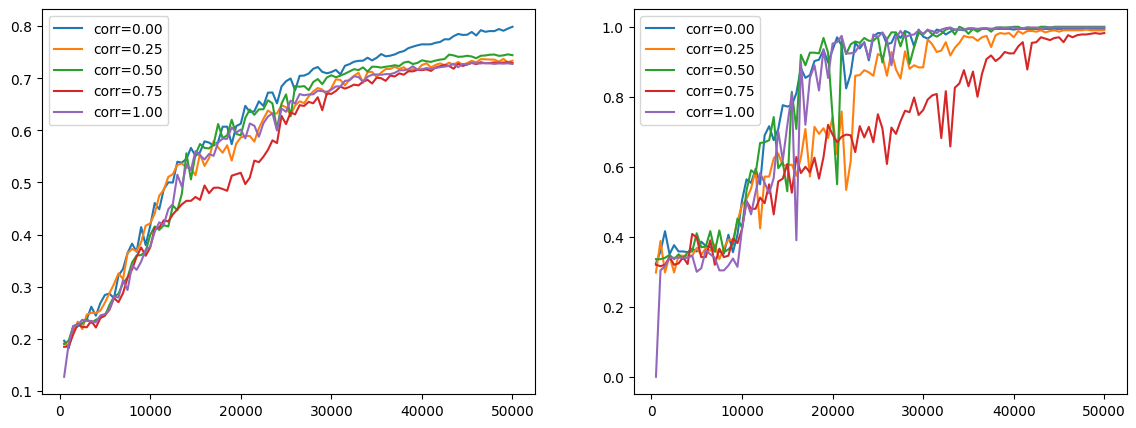

In [42]:
fig,ax = plt.subplots(1,2, figsize=(14,5))
for corr in [0.00, 0.25, 0.50, 0.75, 1.00]:
    hist = torch.load(HIST_DIR / f"pretrain_corr_{corr:.2f}_history.pth", map_location="cpu")   
    ax[0].plot(hist["steps"], hist["val"]['all_other_avg']['answer_acc'], label=f"corr={corr:.2f}")
    ax[1].plot(hist["steps"], hist["val"]['count_b']['answer_acc'], label=f"corr={corr:.2f}")

ax[0].legend()
ax[1].legend()


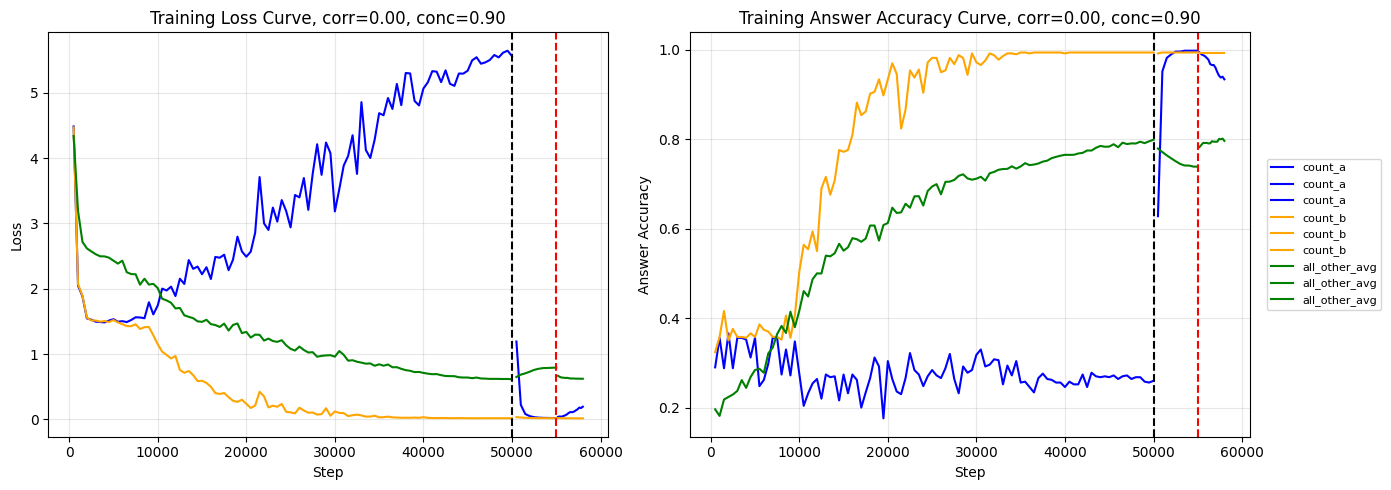

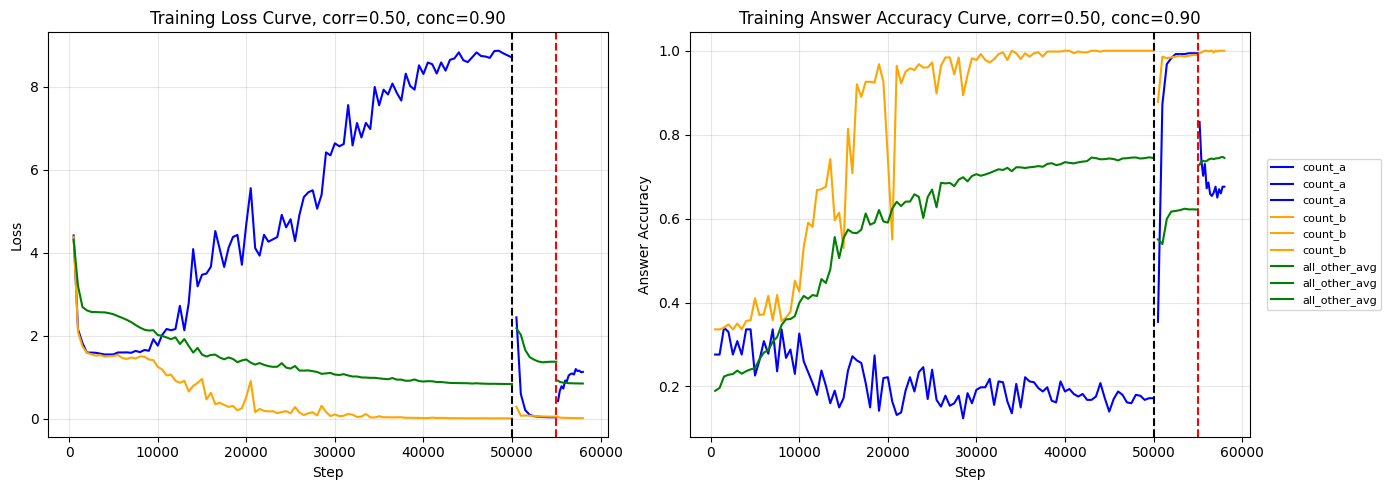

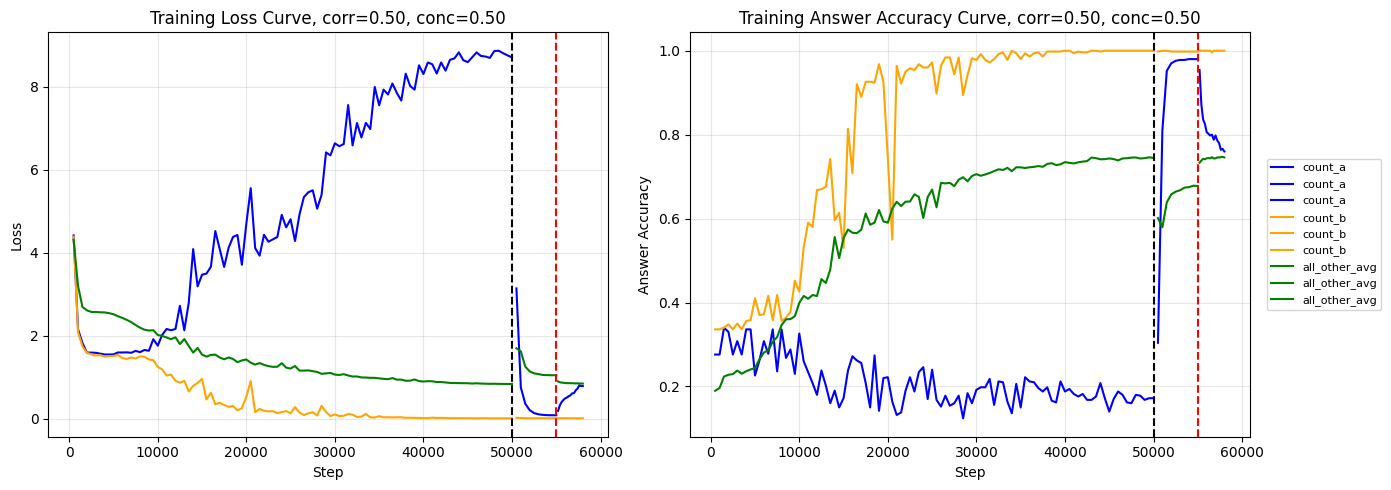

In [44]:


for (corr, conc) in [(0.00, 0.90), (0.50, 0.90), (0.50, 0.50)]:
# for (corr, conc) in [(0.00, 0.10), (0.25, 0.10), (0.00, 0.90), (0.50, 0.90), (0.50, 0.50)]:
# hist = torch.load(HIST_DIR / f"pretrain_corr_{corr}_history.pth", map_location="cpu")
    # hist_ft = torch.load(HIST_DIR / f"finetune_corr_{corr}_conc_{conc}_history.pth", map_location="cpu")
    hist = torch.load(HIST_DIR / f"pretrain_corr_{corr:.2f}_history.pth", map_location="cpu")   
    hist_ft = torch.load(HIST_DIR / f"finetune_corr_{corr:.2f}_conc_{conc:.2f}_history.pth", map_location="cpu")
    history_forget = torch.load(HIST_DIR / f"reverse_corr_{corr:.2f}_conc_{conc:.2f}_history.pth", map_location="cpu")

    fig,ax= plt.subplots(1,2, figsize=(14,5))
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    for i in range(len(hist['val'].keys())):
        split = list(hist['val'].keys())[i]
        val_loss = hist['val'][split]['loss']
        val_acc = hist['val'][split]['answer_acc']
        ax[0].plot(hist['steps'][:len(val_loss)], val_loss, label=split, color=colors[i])
        ax[0].plot(np.array(hist_ft['steps'][:len(val_loss)]) + hist['steps'][-1], hist_ft['val'][split]['loss'], label=split, color=colors[i])
        ax[0].plot(np.array(history_forget['steps'][:len(val_loss)]) + hist['steps'][-1] + hist_ft['steps'][-1], history_forget['val'][split]['loss'], label=split, color=colors[i], )
        ax[1].plot(hist['steps'][:len(val_acc)], val_acc, label=split, color=colors[i])
        ax[1].plot(np.array(hist_ft['steps'][:len(val_acc)]) + hist['steps'][-1], hist_ft['val'][split]['answer_acc'], label=split, color=colors[i])
        ax[1].plot(np.array(history_forget['steps'][:len(val_acc)]) + hist['steps'][-1] + hist_ft['steps'][-1], history_forget['val'][split]['answer_acc'], label=split, color=colors[i], )

    # Draw vertical lines at the start of finetune and forget
    ax[0].axvline(hist['steps'][-1], color='black', linestyle='--', label='finetune start' if i == 0 else None)
    ax[0].axvline(hist['steps'][-1] + hist_ft['steps'][-1], color='red', linestyle='--', label='forget start' if i == 0 else None)
    ax[1].axvline(hist['steps'][-1], color='black', linestyle='--', label='finetune start' if i == 0 else None)
    ax[1].axvline(hist['steps'][-1] + hist_ft['steps'][-1], color='red', linestyle='--', label='forget start' if i == 0 else None)
    ax[0].set_title("Training Loss Curve, corr={:.2f}, conc={:.2f}".format(corr, conc))
    ax[0].set_xlabel("Step")
    ax[0].set_ylabel("Loss")
    ax[0].grid(alpha=0.3)
    ax[1].set_title("Training Answer Accuracy Curve, corr={:.2f}, conc={:.2f}".format(corr, conc))
    ax[1].set_xlabel("Step")
    ax[1].set_ylabel("Answer Accuracy")
    ax[1].grid(alpha=0.3)
    ax[1].legend(loc="center left", bbox_to_anchor=(1.02,0.5), fontsize=8)
    plt.tight_layout()
    plt.show()


In [ ]:
corr = 0.00
conc = 0.90

corr = 0.75
conc = 0.90

hist = torch.load(HIST_DIR / f"pretrain_corr_{corr:.2f}_history.pth", map_location="cpu")   
hist_ft = torch.load(HIST_DIR / f"finetune_corr_{corr:.2f}_conc_{conc:.2f}_history.pth", map_location="cpu")
history_forget = torch.load(HIST_DIR / f"reverse_corr_{corr:.2f}_conc_{conc:.2f}_history.pth", map_location="cpu")